In [1]:
from qiskit.quantum_info import Statevector, Operator, partial_trace, SparsePauliOp
from qiskit import qpy, QuantumCircuit
import numpy as np
from qiskit.synthesis import TwoQubitWeylDecomposition
from qiskit_aer import AerSimulator
from QuditsOnQubits import create_ame_circuit, generate_b_ame
from sympy.functions.combinatorial.numbers import legendre_symbol
from IPython.display import display, Math
from itertools import product
from qiskit_aer.primitives import EstimatorV2 as AerEstimator
from qiskit_aer.primitives import SamplerV2 as AerSampler
from qiskit.circuit import QuantumCircuit
from qiskit.circuit.library import StatePreparation
from igraph import Graph, plot
import matplotlib.pyplot as plt
import matplotlib.ticker as tck

In [2]:
with open('Xgate3.qpy', 'rb') as fd:
    Xgate3 = qpy.load(fd)[0]

with open('Zgate3.qpy', 'rb') as fd:
    Zgate3 = qpy.load(fd)[0]

with open('Xgate4.qpy', 'rb') as fd:
    Xgate4 = qpy.load(fd)[0]

with open('Zgate4.qpy', 'rb') as fd:
    Zgate4 = qpy.load(fd)[0]

with open('Xgate3dag.qpy', 'rb') as fd:
    Xgate3dag = qpy.load(fd)[0]

with open('Zgate3dag.qpy', 'rb') as fd:
    Zgate3dag = qpy.load(fd)[0]

with open('Xgate4dag.qpy', 'rb') as fd:
    Xgate4dag = qpy.load(fd)[0]

with open('Zgate4dag.qpy', 'rb') as fd:
    Zgate4dag = qpy.load(fd)[0]

with open('FDAGgate3.qpy', 'rb') as fd:
    FDAGgate3 = qpy.load(fd)[0]

with open('FDAGgate4.qpy', 'rb') as fd:
    FDAGgate4 = qpy.load(fd)[0]

In [3]:
def ed(d):
    if d % 4 == 1:
        return 1
    elif d % 4 == 3:
        return 1j
def ls(n, d):
    return int(legendre_symbol(n, d))
def gnd(n, d):
    if n % 2 == 0 and (n + d + 1)/2 % 2 == 0:
        return n*(n*n - d*(d + 6) + 3)
    elif n % 2 == 0 and (n + d + 1)/2 % 2 == 1:
        return n*(n*n - d*(d - 6) + 3)
    elif n % 4 == 1:
        return n * (n*n + 3) + 2*d*d * (-5*n + 3)
    elif n % 4 == 3:
        return n * (n*n + 3) + 2*d*d * (n + 3)
def omega(d):
    return np.exp( 2j * np.pi / d)
def lam(n, d):
    a = ed(d) * ls(n, d)
    lam_temp = pow(omega(d), -gnd(n, d) / 48) / a
    return lam_temp.conj()

In [4]:
def A_t(t, n):
    a1 = lam(n, 3)/np.sqrt(3)
    M = np.zeros((4,4), dtype=complex)
    X = Operator(Xgate3).data
    Z = Operator(Zgate3).data
    for k in range(3):
        b1 = omega(3)**(n * t * k) * omega(3)**(n * (k * (k + 1)))
        c1 = np.linalg.matrix_power(X @ np.linalg.matrix_power(Z, k), n)  # (XZ^k)^n
        M += b1 * c1

    return a1 * M

def B_k(k, n):
    X = Operator(Xgate3).data
    Z = Operator(Zgate3).data
    mtx = np.linalg.matrix_power(Z @ np.linalg.matrix_power(X, k), n % 3)
    return mtx

def C_k(k, n):
    X = Operator(Xgate3).data
    Z = Operator(Zgate3).data
    if k == 0:
        return np.linalg.matrix_power(Z, n % 3)
    elif k == 1:
        return np.linalg.matrix_power(X, n % 3)

def D_k(k, n):
    X = Operator(Xgate3).data
    Z = Operator(Zgate3).data
    return np.linalg.matrix_power(Z @ np.linalg.matrix_power(X, k), n % 3)

def Op_clas(alfa, n):
    return omega(3)**(n*alfa)

def I_ame_clas(alfa0, alfa1, afla2, beta0, beta1, beta2, gamma0, gamma1, gamma2, delta0, delta1, delta2):

    suma = 0

    for n in range(1, 3):
        A = [Op_clas(alfa0, n), Op_clas(alfa1, n), Op_clas(afla2, n)]
        B = [Op_clas(beta0, n), Op_clas(beta1, n), Op_clas(beta2, n)]
        C = [Op_clas(gamma0, n), Op_clas(gamma1, 2*n), Op_clas(gamma2, n)]
        D = [Op_clas(delta0, n), Op_clas(delta1, 2*n), Op_clas(delta2, n)]

        a1 = 1/(np.sqrt(3) * lam(n, 3))
        a2 = 1/(2 * np.sqrt(3) * lam(n, 3) * omega(3)**(2*n))

        op1 = a1 * ((A[0] + A[1] + A[2]) * B[0] * D[0])
        op2 = a1 * ((A[0] + omega(3)**(-2*n) * A[1] + omega(3)**(-n) * A[2]) * B[2] * C[1] * D[0])
        op3 = a2 * ((A[0] + omega(3)**(-n) * A[1] + omega(3)**(-2*n) * A[2]) * B[1] * C[0] * D[0])
        op4 = a2 * ((A[0] + omega(3)**(-n) * A[1] + omega(3)**(-2*n) * A[2]) * B[0] * C[1] * D[2])
        op5 = B[0] * C[2] * D[1]

        suma += sum([op1, op2, op3, op4, op5])

    return suma

def I_ame(qc):

    suma = 0

    A = [Operator(A_t(0, 1)), Operator(A_t(1, 1)), Operator(A_t(2, 1))]
    B = [Operator(B_k(0, 1)), Operator(B_k(1, 1)), Operator(B_k(2, 1))]
    C0 = Operator(C_k(0, 1))
    C02 = Operator(C_k(0, 2))
    C1 = Operator(C_k(1, 1))
    D0 = Operator(D_k(0, 1))
    D1 = Operator(D_k(1, 1))
    D02 = Operator(D_k(0, 2))
    I = Operator(np.identity(4))

    n1 = 1
    a1 = 1/(np.sqrt(3) * lam(1, 3))
    a2 = 1/(2 * np.sqrt(3) * lam(1, 3) * omega(3)**(2*n1))

    svlist = [Statevector(qc).expectation_value(A[0] ^ B[0] ^ I ^ D0), Statevector(qc).expectation_value(A[1] ^ B[0] ^ I ^ D0), Statevector(qc).expectation_value(A[2] ^ B[0] ^ I ^ D0), Statevector(qc).expectation_value(A[0] ^ B[2] ^ C02 ^ D0), Statevector(qc).expectation_value(A[1] ^ B[2] ^ C02 ^ D0), Statevector(qc).expectation_value(A[2] ^ B[2] ^ C02 ^ D0), Statevector(qc).expectation_value(A[0] ^ B[1] ^ C0 ^ D0), Statevector(qc).expectation_value(A[1] ^ B[1] ^ C0 ^ D0), Statevector(qc).expectation_value(A[2] ^ B[1] ^ C0 ^ D0), Statevector(qc).expectation_value(A[0] ^ B[0] ^ C02 ^ D1), Statevector(qc).expectation_value(A[1] ^ B[0] ^ C02 ^ D1), Statevector(qc).expectation_value(A[2] ^ B[0] ^ C02 ^ D1), Statevector(qc).expectation_value(I ^ B[0] ^ C1 ^ D02)]


    op1 = a1 * (svlist[0] + svlist[1] + svlist[2])
    #op2 = np.kron(np.kron(np.kron((A[0] + omega(3)**2 * A[1] + omega(3) * A[2]), B[2]), C02), D0)
    op2 = a1 * (svlist[3] + omega(3)**(-2*n1) * svlist[4] + omega(3)**(-n1) * svlist[5])
    #op3 = np.kron(np.kron(np.kron((A[0] + omega(3) * A[1] + omega(3)**2 * A[2]), B[1]), C0), D0)
    op3 = a2 * (svlist[6] + omega(3)**(-n1) * svlist[7] + omega(3)**(-2*n1) * svlist[8])
    #op4 = np.kron(np.kron(np.kron((A[0] + omega(3) * A[1] + omega(3)**2 * A[2]), B[0]), C02), D1)
    op4 = a2 * (svlist[9] + omega(3)**(-n1) * svlist[10] + omega(3)**(-2*n1) * svlist[11])
    #op5 = np.kron(np.kron(np.kron(I, B[0]), C1), D0)
    op5 = svlist[12]

    op_list = [op1, op2, op3, op4, op5]

    #ev_list = [Statevector(qc).expectation_value(op) for op in op_list]

    for s in svlist:
        print(s.round(3))

    suma += sum(op_list)

    # for i in op_list:
    #     print(i.round(3))

    #CC
    A = [Operator(A_t(0, 2)), Operator(A_t(1, 2)), Operator(A_t(2, 2))]
    B = [Operator(B_k(0, 2)), Operator(B_k(1, 2)), Operator(B_k(2, 2))]
    C0 = Operator(C_k(0, 2))
    C02 = Operator(C_k(0, 4))
    C1 = Operator(C_k(1, 2))
    D0 = Operator(D_k(0, 2))
    D1 = Operator(D_k(1, 2))
    D02 = Operator(D_k(0, 4))
    I = Operator(np.identity(4))

    n1 = 2

    #op1 = np.kron(np.kron(np.kron((A[0] + A[1] + A[2]), B[0]), I), D0)
    a1 = 1/(np.sqrt(3) * lam(2, 3))
    a2 = 1/(2 * np.sqrt(3) * lam(2, 3) * omega(3)**(2*n1))

    svlist = [Statevector(qc).expectation_value(A[0] ^ B[0] ^ I ^ D0), Statevector(qc).expectation_value(A[1] ^ B[0] ^ I ^ D0), Statevector(qc).expectation_value(A[2] ^ B[0] ^ I ^ D0), Statevector(qc).expectation_value(A[0] ^ B[2] ^ C02 ^ D0), Statevector(qc).expectation_value(A[1] ^ B[2] ^ C02 ^ D0), Statevector(qc).expectation_value(A[2] ^ B[2] ^ C02 ^ D0), Statevector(qc).expectation_value(A[0] ^ B[1] ^ C0 ^ D0), Statevector(qc).expectation_value(A[1] ^ B[1] ^ C0 ^ D0), Statevector(qc).expectation_value(A[2] ^ B[1] ^ C0 ^ D0), Statevector(qc).expectation_value(A[0] ^ B[0] ^ C02 ^ D1), Statevector(qc).expectation_value(A[1] ^ B[0] ^ C02 ^ D1), Statevector(qc).expectation_value(A[2] ^ B[0] ^ C02 ^ D1), Statevector(qc).expectation_value(I ^ B[0] ^ C1 ^ D02)]


    op1 = a1 * (svlist[0] + svlist[1] + svlist[2])
    #op2 = np.kron(np.kron(np.kron((A[0] + omega(3)**2 * A[1] + omega(3) * A[2]), B[2]), C02), D0)
    op2 = a1 * (svlist[3] + omega(3)**(-2*n1) * svlist[4] + omega(3)**(-n1) * svlist[5])
    #op3 = np.kron(np.kron(np.kron((A[0] + omega(3) * A[1] + omega(3)**2 * A[2]), B[1]), C0), D0)
    op3 = a2 * (svlist[6] + omega(3)**(-n1) * svlist[7] + omega(3)**(-2*n1) * svlist[8])
    #op4 = np.kron(np.kron(np.kron((A[0] + omega(3) * A[1] + omega(3)**2 * A[2]), B[0]), C02), D1)
    op4 = a2 * (svlist[9] + omega(3)**(-n1) * svlist[10] + omega(3)**(-2*n1) * svlist[11])
    #op5 = np.kron(np.kron(np.kron(I, B[0]), C1), D0)
    op5 = svlist[12]

    op_list = [op1, op2, op3, op4, op5]

    #ev_list = [Statevector(qc).expectation_value(op) for op in op_list]

    for s in svlist:
        print(s.round(3))

    # for i in op_list:
    #     print(i.round(3))

    suma += sum(op_list)
    return suma

In [4]:
tst = [0, 1, 2, 3]

In [7]:
I_clas_max = I_ame_clas(0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0)
i_max = (0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0)
k = 0
for i in product(range(3), repeat=12):
    if k % 10000 == 0:
        print(k)
    k += 1
    Itemp = I_ame_clas(*i)
    if Itemp > I_clas_max:
        I_clas_max = Itemp
        i_max = i

0


KeyboardInterrupt: 

In [211]:
I_clas_max

np.complex128(7.6381557247154515+8.881784197001252e-16j)

In [5]:
def get_random_index(finish):
    rng = np.random.default_rng()
    res = rng.integers(finish)
    return res

def get_ind(k, l, m, n):
    order = [(0,0,3,0),(1,0,3,0),(2,0,3,0),(0,2,1,0),(1,2,1,0),(2,2,1,0),(0,1,0,0),(1,1,0,0),(2,1,0,0),(0,0,1,1),(1,0,1,1),(2,0,1,1),(3,0,2,2)]
    while True:
        if (k, l, m, n) in order:
            break
        else:
            k = get_random_index(4)
            l = get_random_index(3)
            m = get_random_index(4)
            n = get_random_index(4)

    pos = {t:i for i,t in enumerate(order)}
    return pos[(k,l,m,n)], k, l, m, n

def ABCD_list(k, l, m, n, im, op):
    ind, k, l, m, n = get_ind(k, l, m, n)
    if im:
        Aret = op[1][ind]
    else:
        Aret = op[0][ind]
    return Aret, k, l, m, n

def create_isa_ops(base_qc):
    A_list = [Operator(A_t(0, 1)), Operator(A_t(1, 1)), Operator(A_t(2, 1)), Operator(np.identity(4))]
    B_list = [Operator(B_k(0, 1)), Operator(B_k(1, 1)), Operator(B_k(2, 1))]
    C_list = [Operator(C_k(0, 1)), Operator(C_k(0, 2)), Operator(C_k(1, 1)), Operator(np.identity(4))]
    D_list = [Operator(D_k(0, 1)), Operator(D_k(1, 1)), Operator(D_k(0, 2)), Operator(np.identity(4))]
    I = Operator(np.identity(4))

    A2_list = [Operator(A_t(0, 2)), Operator(A_t(1, 2)), Operator(A_t(2, 2)), Operator(np.identity(4))]
    B2_list = [Operator(B_k(0, 2)), Operator(B_k(1, 2)), Operator(B_k(2, 2))]
    C2_list = [Operator(C_k(0, 2)), Operator(C_k(0, 4)), Operator(C_k(1, 2)), Operator(np.identity(4))]
    D2_list = [Operator(D_k(0, 2)), Operator(D_k(1, 2)), Operator(D_k(0, 4)), Operator(np.identity(4))]

    op_list = []
    op2_list = []

    op_list_im = []
    op2_list_im = []

    for im in [False, True]:
        for ord in [(0,0,3,0),(1,0,3,0),(2,0,3,0),(0,2,1,0),(1,2,1,0),(2,2,1,0),(0,1,0,0),(1,1,0,0),(2,1,0,0),(0,0,1,1),(1,0,1,1),(2,0,1,1),(3,0,2,2)]:
            k = ord[0]
            l = ord[1]
            m = ord[2]
            n = ord[3]

            A = A_list[k]
            B = B_list[l]
            C = C_list[m]
            D = D_list[n]

            A2 = A2_list[k]
            B2 = B2_list[l]
            C2 = C2_list[m]
            D2 = D2_list[n]

            AB = Operator(A) ^ Operator(B) ^ Operator(C) ^ Operator(D)
            AB2 = Operator(A2) ^ Operator(B2) ^ Operator(C2) ^ Operator(D2)
            if im:
                A_op = -0.5j * (AB - AB.adjoint())
                A2_op = -0.5j * (AB2 - AB2.adjoint())
            else:
                A_op = 0.5 * (AB + AB.adjoint())
                A2_op = 0.5 * (AB2 + AB2.adjoint())

            op = SparsePauliOp.from_operator(A_op)
            op2 = SparsePauliOp.from_operator(A2_op)

            op_isa = op.apply_layout(layout=base_qc.layout)
            op2_isa = op2.apply_layout(layout=base_qc.layout)

            if im:
                op_list_im.append(op_isa)
                op2_list_im.append(op2_isa)
            else:
                op_list.append(op_isa)
                op2_list.append(op2_isa)

    return [op_list, op_list_im], [op2_list, op2_list_im]

def calculate_I_g(ev_list_re, ev_list_im):

    for im in [False, True]:
        if im:
            ev_list = ev_list_im
        else:
            ev_list = ev_list_re

        n1 = 1
        a1 = 1/(np.sqrt(3) * lam(1, 3))
        a2 = 1/(2 * np.sqrt(3) * lam(1, 3) * omega(3)**(2*n1))

        op1 = a1 * (ev_list[0] + ev_list[1] + ev_list[2])
        op2 = a1 * (ev_list[3] + omega(3)**(-2*n1) * ev_list[4] + omega(3)**(-n1) * ev_list[5])
        op3 = a2 * (ev_list[6] + omega(3)**(-n1) * ev_list[7] + omega(3)**(-2*n1) * ev_list[8])
        op4 = a2 * (ev_list[9] + omega(3)**(-n1) * ev_list[10] + omega(3)**(-2*n1) * ev_list[11])
        op5 = ev_list[12]

        n2 = 2
        a3 = 1/(np.sqrt(3) * lam(2, 3))
        a4 = 1/(2 * np.sqrt(3) * lam(2, 3) * omega(3)**(2*n2))

        op6 = a3 * (ev_list[13] + ev_list[14] + ev_list[15])
        op7 = a3 * (ev_list[16] + omega(3)**(-2*n2) * ev_list[17] + omega(3)**(-n2) * ev_list[18])
        op8 = a4 * (ev_list[19] + omega(3)**(-n2) * ev_list[20] + omega(3)**(-2*n2) * ev_list[21])
        op9 = a4 * (ev_list[22] + omega(3)**(-n2) * ev_list[23] + omega(3)**(-2*n2) * ev_list[24])
        op10 = ev_list[25]

        op_list = [op1, op2, op3, op4, op5, op6, op7, op8, op9, op10]

        # for i in ev_list:
        #     print(i.round(3))

        if im:
            suma_im = sum(op_list)
        else:
            suma_re = sum(op_list)

    return suma_re + suma_im*1j

def I_g_random(qc, est, shots, op, op2):

    ev_dict_re = {}
    ev_dict_im = {}

    ini_time_for_now = datetime.now()

    print("Start")
    for i in range(shots):
        print("Losowanie indexow")
        k = get_random_index(4)
        l = get_random_index(3)
        m = get_random_index(4)
        n = get_random_index(4)

        kcc = get_random_index(4)
        lcc = get_random_index(3)
        mcc = get_random_index(4)
        ncc = get_random_index(4)

        #Tutaj jest oszustwo bo naraz mierze czesc n=1 i n=2
        AB, k, l, m, n = ABCD_list(k, l, m, n, False, op)
        ABcc, kcc, lcc, mcc, ncc = ABCD_list(kcc, lcc, mcc, ncc, False, op2)
        AB_im, k, l, m, n = ABCD_list(k, l, m, n, True, op)
        ABcc_im, kcc, lcc, mcc, ncc = ABCD_list(kcc, lcc, mcc, ncc, True, op2)

        print("Odpalanie jobow")

        est.options.default_shots = 50
        #est.options.environment.job_tags = ["Estimator", f'Shot {i} of {shots}']
        job = est.run([(qc, AB), (qc, ABcc), (qc, AB_im), (qc, ABcc_im)])

        print("Resulty z jobow")
        # dla RE
        ev = job.result()[0].data.evs
        key_re = (0, (k, l, m, n))
        key_cc = (1, (kcc, lcc, mcc, ncc))
        key_re_im = (0, (k, l, m, n))
        key_cc_im = (1, (kcc, lcc, mcc, ncc))

        if key_re not in ev_dict_re:
            ev_dict_re[key_re] = []
        ev_dict_re[key_re].append(ev)

        evcc = job.result()[1].data.evs

        if key_cc not in ev_dict_re:
            ev_dict_re[key_cc] = []
        ev_dict_re[key_cc].append(evcc)

        # dla IM
        ev_im = job.result()[2].data.evs


        if key_re_im not in ev_dict_im:
            ev_dict_im[key_re_im] = []
        ev_dict_im[key_re_im].append(ev_im)

        evcc_im = job.result()[3].data.evs


        if key_cc_im not in ev_dict_im:
            ev_dict_im[key_cc_im] = []
        ev_dict_im[key_cc_im].append(evcc_im)

        print(f'Indexy: {k} {l} {m} {n}, {kcc} {lcc} {mcc} {ncc}')
        print(f'Evs: {ev} {evcc} {ev_im} {evcc_im}')

        if i == 0:
            time_for_one = datetime.now() - ini_time_for_now
            time_for_all = time_for_one * shots
            print(f'Estimated time for all shots: {time_for_all}')
            print(f'Estimated finish time: {ini_time_for_now + time_for_all}')

        print(f'Shot {i+1} of {shots}')

    mean_ev_list = {}

    for key in ev_dict_re:
        mean_ev_list[key] = np.mean(ev_dict_re[key])

    final_ev_list_re = []

    order = [(0,0,3,0),(1,0,3,0),(2,0,3,0),(0,2,1,0),(1,2,1,0),(2,2,1,0),(0,1,0,0),(1,1,0,0),(2,1,0,0),(0,0,1,1),(1,0,1,1),(2,0,1,1),(3,0,2,2)]

    for ord in order:
        final_ev_list_re.append(mean_ev_list.get((0, ord)))

    for ord in order:
        final_ev_list_re.append(mean_ev_list.get((1, ord)))

    mean_ev_list_im = {}

    for key in ev_dict_im:
        mean_ev_list_im[key] = np.mean(ev_dict_im[key])

    final_ev_list_im = []

    for ord in order:
        final_ev_list_im.append(mean_ev_list_im.get((0, ord)))

    for ord in order:
        final_ev_list_im.append(mean_ev_list_im.get((1, ord)))

    # print(final_ev_list_re)
    # print(final_ev_list_im)
    ig_val = calculate_I_g(final_ev_list_re, final_ev_list_im)

    return ig_val

In [6]:
def Ry01(theta):
    mtx = np.array([
        [np.cos(theta/2), -np.sin(theta/2), 0, 0],
        [np.sin(theta/2), np.cos(theta/2), 0, 0],
        [0, 0, 1, 0],
        [0, 0, 0, 1]
    ])
    return Operator(mtx)

def Ry02(theta):
    mtx = np.array([
        [np.cos(theta/2),   0, -np.sin(theta/2),    0],
        [0,                 1, 0,                   0],
        [np.sin(theta/2),   0, np.cos(theta/2),     0],
        [0,                 0, 0,                   1]
    ])
    return Operator(mtx)

def Ry12(theta):
    mtx = np.array([
        [1, 0, 0, 0],
        [0, np.cos(theta/2), -np.sin(theta/2), 0],
        [0, np.sin(theta/2), np.cos(theta/2), 0],
        [0, 0, 0, 1]
    ])
    return Operator(mtx)

In [7]:
from datetime import datetime, timedelta

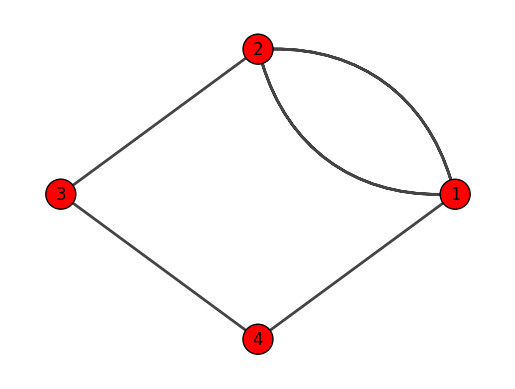

In [8]:
game43 = Graph(n=4, edges=[[0, 1], [0, 1],  [1, 2], [2, 3], [3, 0]])
game43.vs["name"] = [i+1 for i in range(game43.vcount())]
fig, ax = plt.subplots()
plot(game43, target=ax, vertex_label=game43.vs["name"])

In [9]:
ame43_qc, g = create_ame_circuit(dim=3, graph=game43)

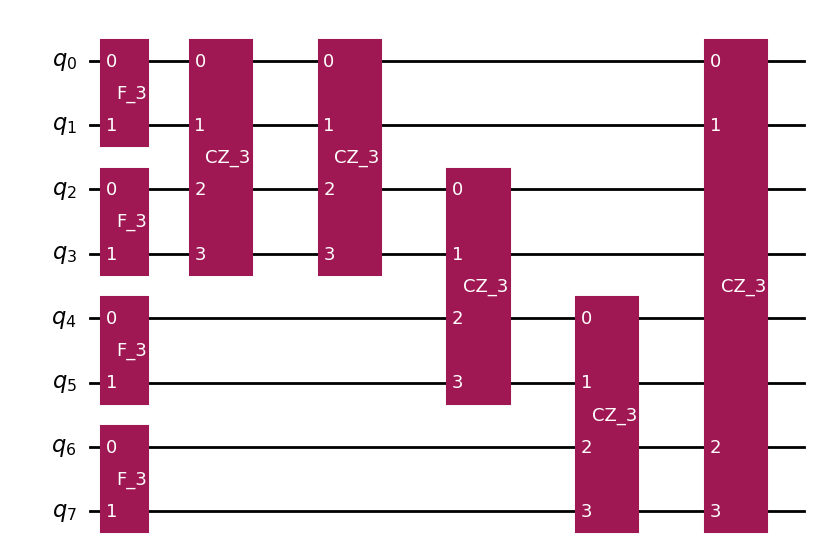

In [10]:
ame43_qc.draw('mpl')

In [38]:
ame43_qc.draw('latex_source')

'\\documentclass[border=2px]{standalone}\n\n\\usepackage[braket, qm]{qcircuit}\n\\usepackage{graphicx}\n\n\\begin{document}\n\\scalebox{1.0}{\n\\Qcircuit @C=1.0em @R=1.0em @!R { \\\\\n\t \t\\nghost{{q}_{0} :  } & \\lstick{{q}_{0} :  } & \\multigate{1}{\\mathrm{F\\_3}}_<<<{0} & \\multigate{3}{\\mathrm{CZ\\_3}}_<<<{0} & \\multigate{3}{\\mathrm{CZ\\_3}}_<<<{0} & \\qw & \\qw & \\multigate{7}{\\mathrm{CZ\\_3}}_<<<{0} & \\qw & \\qw\\\\\n\t \t\\nghost{{q}_{1} :  } & \\lstick{{q}_{1} :  } & \\ghost{\\mathrm{F\\_3}}_<<<{1} & \\ghost{\\mathrm{CZ\\_3}}_<<<{1} & \\ghost{\\mathrm{CZ\\_3}}_<<<{1} & \\qw & \\qw & \\ghost{\\mathrm{CZ\\_3}}_<<<{1} & \\qw & \\qw\\\\\n\t \t\\nghost{{q}_{2} :  } & \\lstick{{q}_{2} :  } & \\multigate{1}{\\mathrm{F\\_3}}_<<<{0} & \\ghost{\\mathrm{CZ\\_3}}_<<<{2} & \\ghost{\\mathrm{CZ\\_3}}_<<<{2} & \\multigate{3}{\\mathrm{CZ\\_3}}_<<<{0} & \\qw & \\ghost{\\mathrm{CZ\\_3}} & \\qw & \\qw\\\\\n\t \t\\nghost{{q}_{3} :  } & \\lstick{{q}_{3} :  } & \\ghost{\\mathrm{F\\_3}}_<<<{1}

In [12]:
I_ame(ame43_qc)

(0.569+0.1j)
(0.569+0.1j)
(0.569+0.1j)
(0.569+0.1j)
(-0.197-0.543j)
(-0.371+0.442j)
(-0.197-0.543j)
(0.569+0.1j)
(-0.371+0.442j)
(-0.197-0.543j)
(0.569+0.1j)
(-0.371+0.442j)
(1-0j)
(0.569-0.1j)
(0.569-0.1j)
(0.569-0.1j)
(0.569-0.1j)
(-0.197+0.543j)
(-0.371-0.442j)
(-0.197+0.543j)
(0.569-0.1j)
(-0.371-0.442j)
(-0.197+0.543j)
(0.569-0.1j)
(-0.371-0.442j)
(1-0j)


np.complex128(8-8.199391430272763e-15j)

In [11]:
op1, op2 = create_isa_ops(ame43_qc)

In [12]:
est = AerEstimator()

In [192]:
I_g_random(ame43_qc.decompose().decompose().decompose(), est, 75, op1, op2)

Start
Losowanie indexow
Odpalanie jobow
Resulty z jobow
Indexy: 0 0 1 1, 2 0 3 0
Evs: -0.19746542181735105 0.5685790213016327 -0.5425317875662524 -0.10025582212029097
Estimated time for all shots: 0:11:31.622850
Estimated finish time: 2025-09-16 17:06:20.200874
Shot 1 of 75
Losowanie indexow
Odpalanie jobow
Resulty z jobow
Indexy: 1 0 1 1, 2 2 1 0
Evs: 0.5685790213016318 -0.37111359948428396 0.10025582212028998 -0.44227596544595976
Shot 2 of 75
Losowanie indexow
Odpalanie jobow
Resulty z jobow
Indexy: 0 2 1 0, 1 2 1 0
Evs: 0.5685790213016318 -0.1974654218173482 0.10025582212029026 0.5425317875662528
Shot 3 of 75
Losowanie indexow
Odpalanie jobow
Resulty z jobow
Indexy: 1 0 3 0, 1 2 1 0
Evs: 0.5685790213016321 -0.1974654218173482 0.10025582212029101 0.5425317875662528
Shot 4 of 75
Losowanie indexow
Odpalanie jobow
Resulty z jobow
Indexy: 1 1 0 0, 2 0 1 1
Evs: 0.5685790213016333 -0.37111359948428196 0.1002558221202903 -0.44227596544596026
Shot 5 of 75
Losowanie indexow
Odpalanie jobow
Re

np.complex128(7.750000000000047-0.14433756729741465j)

In [11]:
def calculate_I_g_std(std_list_re, std_list_im):

    for im in [False, True]:
        if im:
            ev_list = std_list_im
        else:
            ev_list = std_list_re

        n1 = 1
        a1 = 1/(np.sqrt(3) * lam(1, 3))
        a2 = 1/(2 * np.sqrt(3) * lam(1, 3) * omega(3)**(2*n1))

        var1  = (abs(a1)**2) * ((ev_list[0])**2 + (ev_list[1])**2 + (ev_list[2])**2)
        var2  = (abs(a1)**2) * ((ev_list[3])**2 + (abs(omega(3)**(-2*n1))**2) * (ev_list[4])**2 + (abs(omega(3)**(-n1))**2) * (ev_list[5])**2)
        var3  = (abs(a2)**2) * ((ev_list[6])**2 + (abs(omega(3)**(-n1))**2) * (ev_list[7])**2 + (abs(omega(3)**(-2*n1))**2) * (ev_list[8])**2)
        var4  = (abs(a2)**2) * ((ev_list[9])**2 + (abs(omega(3)**(-n1))**2) * (ev_list[10])**2 + (abs(omega(3)**(-2*n1))**2) * (ev_list[11])**2)
        var5  = (ev_list[12])**2

        n2 = 2
        a3 = 1/(np.sqrt(3) * lam(2, 3))
        a4 = 1/(2 * np.sqrt(3) * lam(2, 3) * omega(3)**(2*n2))

        var6  = (abs(a3)**2) * ((ev_list[13])**2 + (ev_list[14])**2 + (ev_list[15])**2)
        var7  = (abs(a3)**2) * ((ev_list[16])**2 + (abs(omega(3)**(-2*n2))**2) * (ev_list[17])**2 + (abs(omega(3)**(-n2))**2) * (ev_list[18])**2)
        var8  = (abs(a4)**2) * ((ev_list[19])**2 + (abs(omega(3)**(-n2))**2) * (ev_list[20])**2 + (abs(omega(3)**(-2*n2))**2) * (ev_list[21])**2)
        var9  = (abs(a4)**2) * ((ev_list[22])**2 + (abs(omega(3)**(-n2))**2) * (ev_list[23])**2 + (abs(omega(3)**(-2*n2))**2) * (ev_list[24])**2)
        var10 = (ev_list[25])**2

        var_list = [var1, var2, var3, var4, var5, var6, var7, var8, var9, var10]


        # for i in ev_list:
        #     print(i.round(3))

        if im:
            suma_im = sum(var_list)
        else:
            suma_re = sum(var_list)

    return suma_re + suma_im*1j

In [12]:
from itertools import chain
import math

def split_equal(seq, parts, length):
    size = length // parts
    return [seq[i:i+size] for i in range(0, length, size)]

def prepare_pubs(qc, shots, op, op2, div_jobs):
    pubs = []

    k_list, l_list, m_list, n_list = [], [], [], []
    kcc_list, lcc_list, mcc_list, ncc_list = [], [], [], []

    for i in range(shots):

        k = get_random_index(4)
        l = get_random_index(3)
        m = get_random_index(4)
        n = get_random_index(4)

        kcc = get_random_index(4)
        lcc = get_random_index(3)
        mcc = get_random_index(4)
        ncc = get_random_index(4)

        #Tutaj jest oszustwo bo naraz mierze czesc n=1 i n=2
        AB, k, l, m, n = ABCD_list(k, l, m, n, False, op)
        ABcc, kcc, lcc, mcc, ncc = ABCD_list(kcc, lcc, mcc, ncc, False, op2)
        AB_im, k, l, m, n = ABCD_list(k, l, m, n, True, op)
        ABcc_im, kcc, lcc, mcc, ncc = ABCD_list(kcc, lcc, mcc, ncc, True, op2)
        pubs.append((qc, [AB, ABcc, AB_im, ABcc_im]))

        k_list.append(k)
        l_list.append(l)
        m_list.append(m)
        n_list.append(n)
        kcc_list.append(kcc)
        lcc_list.append(lcc)
        mcc_list.append(mcc)
        ncc_list.append(ncc)

    pub_cuts = split_equal(pubs, div_jobs, shots)

    return pub_cuts, k_list, l_list, m_list, n_list, kcc_list, lcc_list, mcc_list, ncc_list

def I_g_stat(est, pub_cuts, k, res):
    parts = []

    for p, num in zip(pub_cuts, range(len(pub_cuts))):
        print(f'{k} of {res}, Jobs num: {num + 1}')
        #est.options.environment.job_tags = [f'Job {num + 1}']
        parts.append(est.run(p))

    return parts

def I_g_from_results_with_std(parts, k_list, l_list, m_list, n_list, kcc_list, lcc_list, mcc_list, ncc_list):
    ev_dict_re = {}
    ev_dict_im = {}
    std_dict_re = {}
    std_dict_im = {}

    results = []

    for p in parts:
        try:
            results.append(p.result())
        except:
            continue

    results = list(chain.from_iterable(results))

    for res, k, l, m, n, kcc, lcc, mcc, ncc in zip(range(len(results)), k_list, l_list, m_list, n_list, kcc_list, lcc_list, mcc_list, ncc_list):
        # Wartości oczekiwane

        ev = results[res].data.evs[0]
        evcc = results[res].data.evs[1]
        ev_im = results[res].data.evs[2]
        evcc_im = results[res].data.evs[3]

        if math.isnan(ev) or math.isnan(evcc) or math.isnan(ev_im) or math.isnan(evcc_im):
            print("Ev NaN")
            continue
        else:
            print('EV OK')
            # Standardowe odchylenia
            std = results[res].data.stds[0]
            stdcc = results[res].data.stds[1]
            std_im = results[res].data.stds[2]
            stdcc_im = results[res].data.stds[3]

            # Zapisywanie do słowników

            key_re = (0, (k, l, m, n))
            key_cc = (1, (kcc, lcc, mcc, ncc))

            if key_re not in ev_dict_re:
                ev_dict_re[key_re] = []
                std_dict_re[key_re] = []
            ev_dict_re[key_re].append(ev)
            std_dict_re[key_re].append(std**2)  # Wariancje dla uśredniania

            if key_cc not in ev_dict_re:
                ev_dict_re[key_cc] = []
                std_dict_re[key_cc] = []
            ev_dict_re[key_cc].append(evcc)
            std_dict_re[key_cc].append(stdcc**2)

            # Analogicznie dla części urojonej
            if key_re not in ev_dict_im:
                ev_dict_im[key_re] = []
                std_dict_im[key_re] = []
            ev_dict_im[key_re].append(ev_im)
            std_dict_im[key_re].append(std_im**2)

            if key_cc not in ev_dict_im:
                ev_dict_im[key_cc] = []
                std_dict_im[key_cc] = []
            ev_dict_im[key_cc].append(evcc_im)
            std_dict_im[key_cc].append(stdcc_im**2)

    # Uśrednianie wartości oczekiwanych i wariancji
    mean_ev_list_re = {}
    mean_std_list_re = {}

    for key in ev_dict_re:
        mean_ev_list_re[key] = np.mean(ev_dict_re[key])
        mean_std_list_re[key] = np.sqrt(np.mean(std_dict_re[key]) / len(std_dict_re[key]))

    mean_ev_list_im = {}
    mean_std_list_im = {}
    for key in ev_dict_im:
        mean_ev_list_im[key] = np.mean(ev_dict_im[key])
        mean_std_list_im[key] = np.sqrt(np.mean(std_dict_im[key]) / len(std_dict_im[key]))

    # Tworzenie list w odpowiedniej kolejności
    final_ev_list_re = []
    final_std_list_re = []

    order = [(0,0,3,0),(1,0,3,0),(2,0,3,0),(0,2,1,0),(1,2,1,0),(2,2,1,0),(0,1,0,0),(1,1,0,0),(2,1,0,0),(0,0,1,1),(1,0,1,1),(2,0,1,1),(3,0,2,2)]

    for ord in order:
        final_ev_list_re.append(mean_ev_list_re.get((0, ord)))
        final_std_list_re.append(mean_std_list_re.get((0, ord)))

    for ord in order:
        final_ev_list_re.append(mean_ev_list_re.get((1, ord)))
        final_std_list_re.append(mean_std_list_re.get((1, ord)))

    final_ev_list_im = []
    final_std_list_im = []

    for ord in order:
        final_ev_list_im.append(mean_ev_list_im.get((0, ord)))
        final_std_list_im.append(mean_std_list_im.get((0, ord)))

    for ord in order:
        final_ev_list_im.append(mean_ev_list_im.get((1, ord)))
        final_std_list_im.append(mean_std_list_im.get((1, ord)))

    ig_val = calculate_I_g(final_ev_list_re, final_ev_list_im)
    ig_std = calculate_I_g_std(final_std_list_re, final_std_list_im)

    return ig_val, ig_std

In [13]:
def prepare_chsh(start, stop, resolution, qc):
    theta_list = np.linspace(start, stop, resolution)

    ry01_list = [Ry01(theta) for theta in theta_list]
    ry01_qc_list = [TwoQubitWeylDecomposition(ry).circuit() for ry in ry01_list]

    for ry in ry01_qc_list:
        ry.name = "Ry01"

    qc01_list = []
    op1list = []
    op2list = []

    for ry in ry01_qc_list:
        qctemp = qc.copy()
        qctemp.append(ry, [0, 1])
        qctemp_isa = pm.run(qctemp)
        qc01_list.append(qctemp_isa)
        op1, op2 = create_isa_ops(qctemp_isa)
        op1list.append(op1)
        op2list.append(op2)

    return qc01_list, theta_list, op1list, op2list

def chsh_pub_cuts(qc01_list, oplist, oplist2, shots, div):
    pub_cuts_list = []
    k_list_list, l_list_list, m_list_list, n_list_list = [], [], [], []
    kcc_list_list, lcc_list_list, mcc_list_list, ncc_list_list = [], [], [], []


    for qc, op1, op2 in zip(qc01_list, oplist, oplist2):
        pub_cuts, k_list, l_list, m_list, n_list, kcc_list, lcc_list, mcc_list, ncc_list = prepare_pubs(qc, shots, op1, op2, div)
        pub_cuts_list.append(pub_cuts)
        k_list_list.append(k_list)
        l_list_list.append(l_list)
        m_list_list.append(m_list)
        n_list_list.append(n_list)
        kcc_list_list.append(kcc_list)
        lcc_list_list.append(lcc_list)
        mcc_list_list.append(mcc_list)
        ncc_list_list.append(ncc_list)

    return pub_cuts_list, k_list_list, l_list_list, m_list_list, n_list_list, kcc_list_list, lcc_list_list, mcc_list_list, ncc_list_list

def chsh_jobs(est, pub_cuts_list, res):
    parts_list = []

    for pub_cuts, k in zip(pub_cuts_list, range(len(pub_cuts_list))):
        parts = I_g_stat(est, pub_cuts, k, res)
        parts_list.append(parts)

    return parts_list


def chsh_results(parts_list, k_list_list, l_list_list, m_list_list, n_list_list, kcc_list_list, lcc_list_list, mcc_list_list, ncc_list_list):
    igval_list = []
    stds_list = []

    for parts, k_list, l_list, m_list, n_list, kcc_list, lcc_list, mcc_list, ncc_list, num_ind in zip(parts_list, k_list_list, l_list_list, m_list_list, n_list_list, kcc_list_list, lcc_list_list, mcc_list_list, ncc_list_list, range(len(parts_list))):
        print(f'Results for {num_ind + 1} of {len(parts_list)}')
        ig, stds = I_g_from_results_with_std(parts, k_list, l_list, m_list, n_list, kcc_list, lcc_list, mcc_list, ncc_list)
        print(ig)
        igval_list.append(ig)
        stds_list.append(np.abs(stds))

    return igval_list, stds_list

def chsh_plot(igval_list, stds_list, theta_list):
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.errorbar(
        theta_list / np.pi,
        np.real(igval_list),
        yerr=stds_list,
        fmt="o-",                 # styl punktów i linii
        capsize=5,                # „daszki” na końcach
        color="red",
        label="Ry01"
    )
    ax.axhline(y=7.6381, linestyle="--")
    ax.xaxis.set_major_formatter(tck.FormatStrFormatter("%g $\\pi$"))
    plt.xlabel("Theta")
    plt.ylabel("Imax")
    plt.legend()
    plt.show()

In [18]:
def chsh(start, stop, resolution, qc, shots, div, session=False):
    qc01_list, theta_list, oplist, oplist2 = prepare_chsh(start, stop, resolution, qc)
    pub_cuts_list, k_list_list, l_list_list, m_list_list, n_list_list, kcc_list_list, lcc_list_list, mcc_list_list, ncc_list_list = chsh_pub_cuts(qc01_list, oplist, oplist2, shots, div)

    if session:
        with Batch(backend=backend) as batch:
            est = Estimator()
            est.options.default_shots = 600
            est.options.resilience_level = 2
            est.options.resilience.zne_mitigation = True
            est.options.resilience.zne.noise_factors = [1, 2, 3, 4, 5]
            est.options.resilience.zne.extrapolator = "exponential"


            parts_list = chsh_jobs(est, pub_cuts_list, resolution)

        print("End of session.")
    else:
        est = AerEstimator()
        parts_list = chsh_jobs(est, pub_cuts_list, resolution)
    igval_list, stds_list = chsh_results(parts_list, k_list_list, l_list_list, m_list_list, n_list_list, kcc_list_list, lcc_list_list, mcc_list_list, ncc_list_list)
    chsh_plot(igval_list, stds_list, theta_list)

    with open("listy_ame43_poly3.txt", "w") as f:
        for i in range(len(k_list_list)):
            f.write(f"{k_list_list[i]}, {l_list_list[i]}, {m_list_list[i]}, {n_list_list[i]}, {kcc_list_list[i]}, {lcc_list_list[i]}, {mcc_list_list[i]}, {ncc_list_list[i]}")
            f.write("\n")

    return igval_list, stds_list, theta_list, [k_list_list, l_list_list, m_list_list, n_list_list, kcc_list_list, lcc_list_list, mcc_list_list, ncc_list_list]

In [15]:
est = AerEstimator()
est.options.default_shots = 5

In [15]:
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import Session, Batch

In [16]:
backend = QiskitRuntimeService().backend("ibm_kingston")
target = backend.target

qiskit_runtime_service._resolve_cloud_instances:WARNING:2025-11-27 19:03:48,395: Default instance not set. Searching all available instances.


In [17]:
pm = generate_preset_pass_manager(target=target, optimization_level=3)

0 of 1, Jobs num: 1
0 of 1, Jobs num: 2
0 of 1, Jobs num: 3
0 of 1, Jobs num: 4
Results for 1 of 1
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
(8.000000000000036-6.747423824845972e-15j)


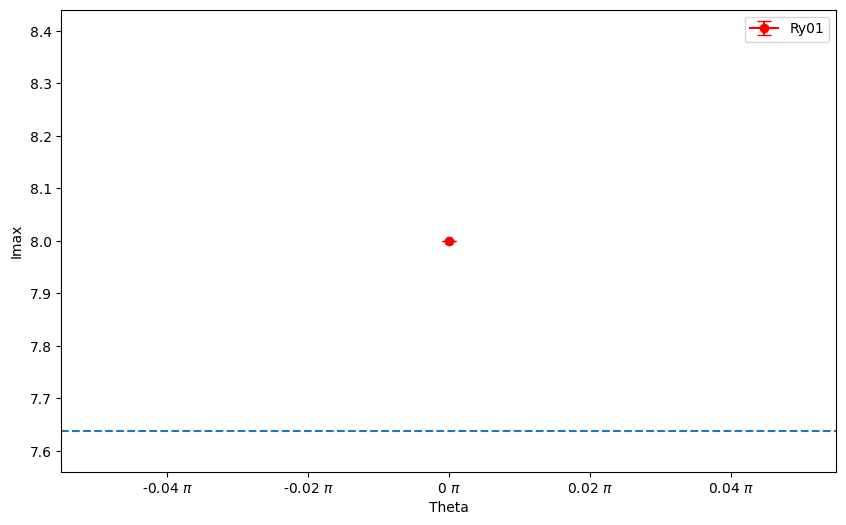

ValueError: too many values to unpack (expected 3)

In [23]:
igvals, stds, thetas = chsh(0, 2*np.pi, 1, ame43_qc, 80, 4, session=False)

0 of 1, Jobs num: 1
0 of 1, Jobs num: 2
0 of 1, Jobs num: 3
0 of 1, Jobs num: 4
End of session.
Results for 1 of 1
EV OK
EV OK
Ev NaN
Ev NaN
EV OK
EV OK
EV OK
Ev NaN
EV OK
Ev NaN
Ev NaN
Ev NaN
EV OK
Ev NaN
Ev NaN
EV OK
EV OK
EV OK
EV OK
Ev NaN
EV OK
EV OK
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
Ev NaN
EV OK
EV OK
EV OK
Ev NaN
Ev NaN
Ev NaN
EV OK
Ev NaN
EV OK
EV OK
EV OK
Ev NaN
EV OK
EV OK
EV OK
Ev NaN
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
Ev NaN
EV OK
EV OK
EV OK
Ev NaN
Ev NaN
EV OK
EV OK
EV OK
EV OK
EV OK
Ev NaN
Ev NaN
EV OK
EV OK
Ev NaN
Ev NaN
EV OK
EV OK
Ev NaN
EV OK
(10.369023015043208+0.07330473799656317j)


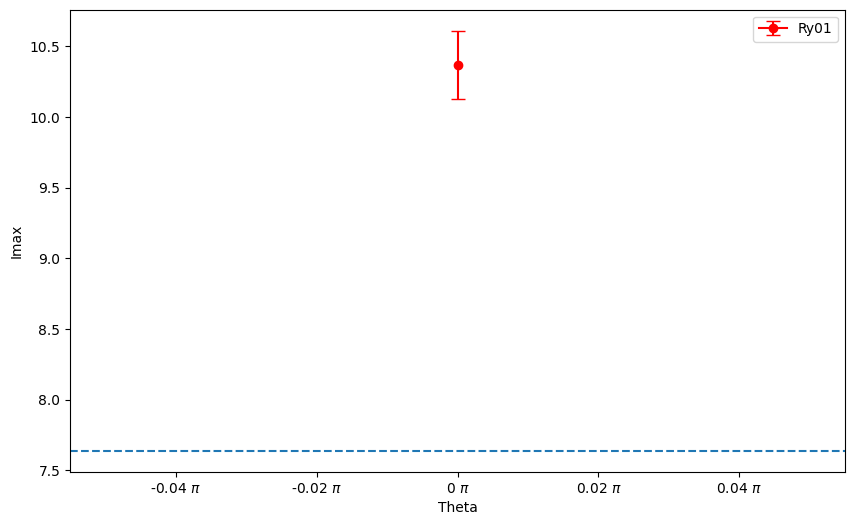

In [24]:
igvals_qc, stds_qc, thetas_qc, listlist = chsh(0, 2*np.pi, 1, ame43_qc, 80, 4, session=True)

0 of 1, Jobs num: 1
0 of 1, Jobs num: 2
0 of 1, Jobs num: 3
End of session.
Results for 1 of 1
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
(5.786245708616659-0.02744710245074838j)


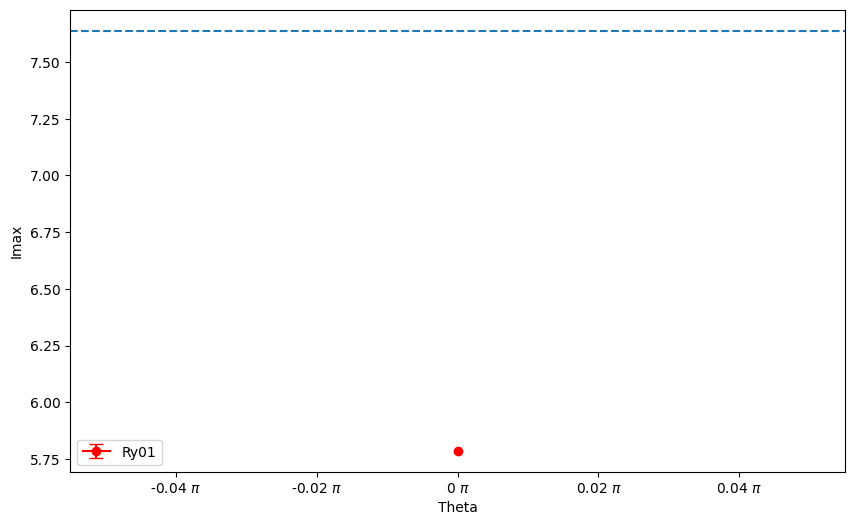

In [90]:
igvals_qc, stds_qc, thetas_qc, listlist = chsh(0, 2*np.pi, 1, ame43_qc, 90, 3, session=True)

0 of 1, Jobs num: 1
0 of 1, Jobs num: 2
0 of 1, Jobs num: 3
End of session.
Results for 1 of 1
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
EV OK
(7.617303435172303-0.020222900167703596j)


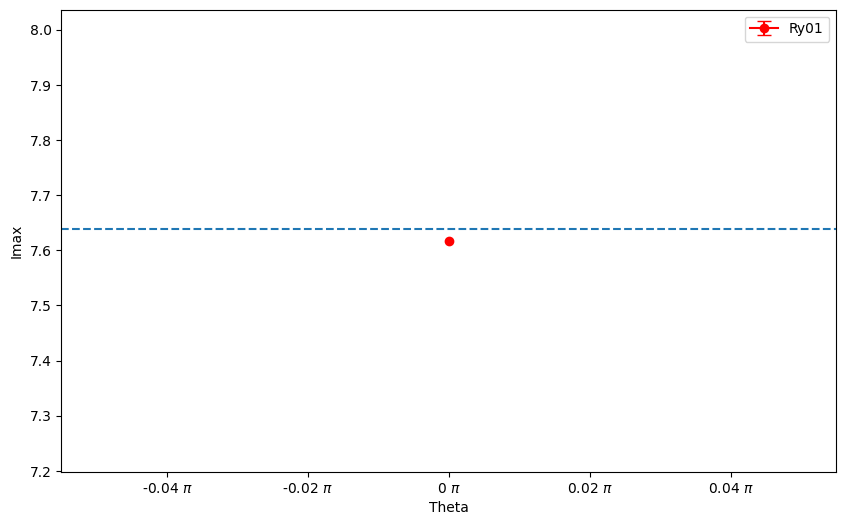

In [92]:
igvals_qc, stds_qc, thetas_qc, listlist = chsh(0, 2*np.pi, 1, ame43_qc, 90, 3, session=True)

In [19]:
igvals_qc, stds_qc, thetas_qc, listlist = chsh(0, 2*np.pi, 1, ame43_qc, 90, 3, session=True)

0 of 1, Jobs num: 1
0 of 1, Jobs num: 2
0 of 1, Jobs num: 3
End of session.
Results for 1 of 1
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN
Ev NaN


TypeError: unsupported operand type(s) for +: 'NoneType' and 'NoneType'

0 of 4, Jobs num: 1
1 of 4, Jobs num: 1
2 of 4, Jobs num: 1
3 of 4, Jobs num: 1
Results for 1 of 4
(-1.194476409147399e-15+6.816905355016907e-16j)
Results for 2 of 4
(6.077350269189624-3.847616669716558e-15j)
Results for 3 of 4
(6.077350269189628-4.739264536368637e-15j)
Results for 4 of 4
(-8.418144158554547e-16+4.905736728415696e-16j)


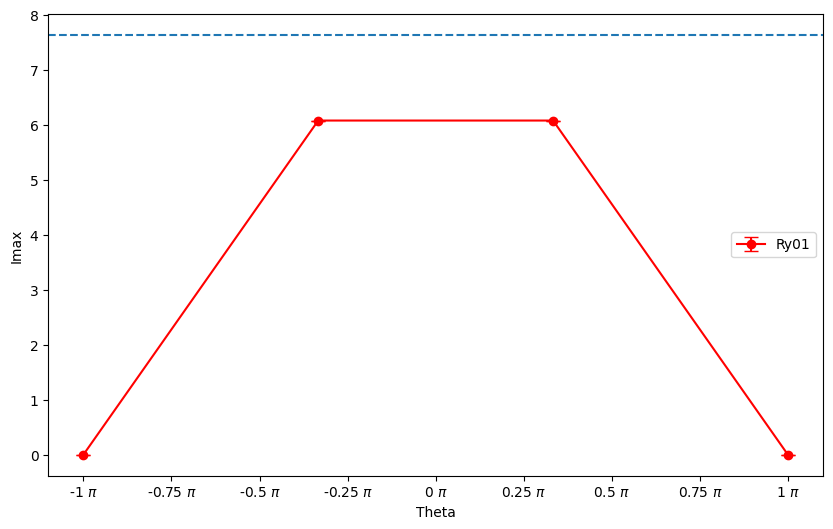

In [17]:
igvals, stds, thetas = chsh(-1*np.pi, 1*np.pi, 4, est, ame43_qc, None, 100, 1)

0 of 5, Jobs num: 1
1 of 5, Jobs num: 1
2 of 5, Jobs num: 1
3 of 5, Jobs num: 1
4 of 5, Jobs num: 1
Results for 1 of 5
(6.875311219358198-5.263151026113633e-15j)
Results for 2 of 5
(7.708081806143539-4.288236432614667e-15j)
Results for 3 of 5
(7.999999999999992-4.812122922359663e-15j)
Results for 4 of 5
(7.708081806143539-5.591013763073249e-15j)
Results for 5 of 5
(6.875311219358201-4.4287490341687885e-15j)


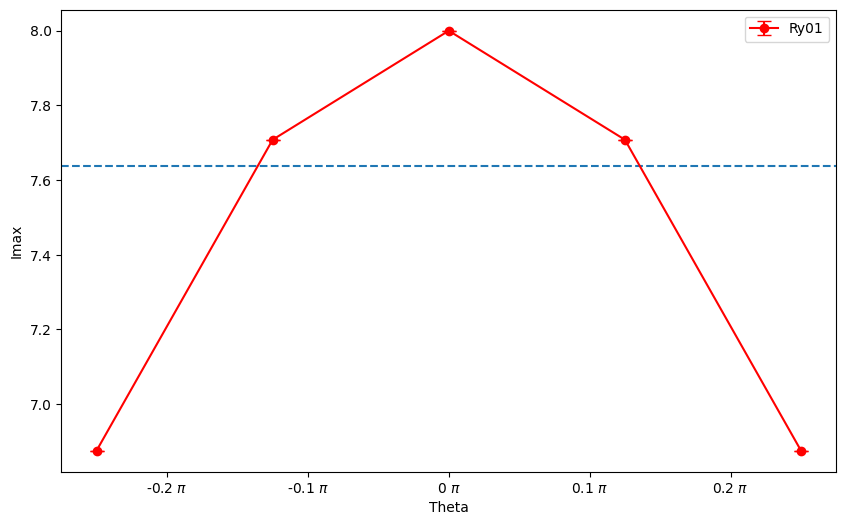

In [18]:
igvals, stds, thetas = chsh(-0.25*np.pi, 0.25*np.pi, 5, est, ame43_qc, None, 100, 1)

In [17]:
est = AerEstimator()

In [ ]:
igvals, stds, thetas = chsh(-0.25*np.pi, 0.25*np.pi, 5, est, ame43_qc, None, 100, 1)

0 of 5, Jobs num: 1
1 of 5, Jobs num: 1
2 of 5, Jobs num: 1
3 of 5, Jobs num: 1
4 of 5, Jobs num: 1


In [30]:
service = QiskitRuntimeService()
job = service.job("d4b6bi9lag1s73bku0h0")

qiskit_runtime_service._resolve_cloud_instances:WARNING:2025-11-20 23:51:15,943: Default instance not set. Searching all available instances.


In [31]:
job.result().metadata

{'dynamical_decoupling': {'enable': False,
  'sequence_type': 'XX',
  'extra_slack_distribution': 'middle',
  'scheduling_method': 'alap'},
 'twirling': {'enable_gates': True,
  'enable_measure': True,
  'num_randomizations': 'auto',
  'shots_per_randomization': 'auto',
  'interleave_randomizations': True,
  'strategy': 'active-accum'},
 'resilience': {'measure_mitigation': True,
  'zne_mitigation': True,
  'pec_mitigation': False,
  'zne': {'noise_factors': [1.0, 3.0, 5.0],
   'extrapolator': ['exponential', 'linear'],
   'extrapolated_noise_factors': [0, 1.0, 3.0, 5.0]}},
 'version': 2}

In [32]:
job.properties().to_dict().get('qubits')[16]

[{'date': datetime.datetime(2025, 11, 13, 4, 28, 59, tzinfo=tzlocal()),
  'name': 'T1',
  'unit': 'us',
  'value': 395.2420011706864},
 {'date': datetime.datetime(2025, 11, 13, 4, 29, 4, tzinfo=tzlocal()),
  'name': 'T2',
  'unit': 'us',
  'value': 302.1521687053538},
 {'date': datetime.datetime(2025, 11, 13, 22, 32, 14, tzinfo=tzlocal()),
  'name': 'readout_error',
  'unit': '',
  'value': 0.017822265625},
 {'date': datetime.datetime(2025, 11, 13, 22, 32, 14, tzinfo=tzlocal()),
  'name': 'prob_meas0_prep1',
  'unit': '',
  'value': 0.016357421875},
 {'date': datetime.datetime(2025, 11, 13, 22, 32, 14, tzinfo=tzlocal()),
  'name': 'prob_meas1_prep0',
  'unit': '',
  'value': 0.019287109375},
 {'date': datetime.datetime(2025, 11, 13, 22, 32, 14, tzinfo=tzlocal()),
  'name': 'readout_length',
  'unit': 'ns',
  'value': 2280}]

In [33]:
job.properties().to_dict().get('qubits')[21]

[{'date': datetime.datetime(2025, 11, 13, 4, 28, 59, tzinfo=tzlocal()),
  'name': 'T1',
  'unit': 'us',
  'value': 306.36537507252797},
 {'date': datetime.datetime(2025, 11, 13, 4, 29, 2, tzinfo=tzlocal()),
  'name': 'T2',
  'unit': 'us',
  'value': 260.83971651105685},
 {'date': datetime.datetime(2025, 11, 13, 22, 32, 14, tzinfo=tzlocal()),
  'name': 'readout_error',
  'unit': '',
  'value': 0.0042724609375},
 {'date': datetime.datetime(2025, 11, 13, 22, 32, 14, tzinfo=tzlocal()),
  'name': 'prob_meas0_prep1',
  'unit': '',
  'value': 0.005615234375},
 {'date': datetime.datetime(2025, 11, 13, 22, 32, 14, tzinfo=tzlocal()),
  'name': 'prob_meas1_prep0',
  'unit': '',
  'value': 0.0029296875},
 {'date': datetime.datetime(2025, 11, 13, 22, 32, 14, tzinfo=tzlocal()),
  'name': 'readout_length',
  'unit': 'ns',
  'value': 2280}]

In [34]:
job.properties().to_dict().get('qubits')[22]

[{'date': datetime.datetime(2025, 11, 13, 4, 28, 59, tzinfo=tzlocal()),
  'name': 'T1',
  'unit': 'us',
  'value': 301.82843392126273},
 {'date': datetime.datetime(2025, 11, 13, 4, 29, 4, tzinfo=tzlocal()),
  'name': 'T2',
  'unit': 'us',
  'value': 116.7417243693205},
 {'date': datetime.datetime(2025, 11, 13, 22, 32, 14, tzinfo=tzlocal()),
  'name': 'readout_error',
  'unit': '',
  'value': 0.007080078125},
 {'date': datetime.datetime(2025, 11, 13, 22, 32, 14, tzinfo=tzlocal()),
  'name': 'prob_meas0_prep1',
  'unit': '',
  'value': 0.008056640625},
 {'date': datetime.datetime(2025, 11, 13, 22, 32, 14, tzinfo=tzlocal()),
  'name': 'prob_meas1_prep0',
  'unit': '',
  'value': 0.006103515625},
 {'date': datetime.datetime(2025, 11, 13, 22, 32, 14, tzinfo=tzlocal()),
  'name': 'readout_length',
  'unit': 'ns',
  'value': 2280}]

In [35]:
job.properties().to_dict().get('qubits')[23]

[{'date': datetime.datetime(2025, 11, 13, 4, 28, 59, tzinfo=tzlocal()),
  'name': 'T1',
  'unit': 'us',
  'value': 184.9803273995443},
 {'date': datetime.datetime(2025, 11, 13, 4, 29, 2, tzinfo=tzlocal()),
  'name': 'T2',
  'unit': 'us',
  'value': 79.22603086211264},
 {'date': datetime.datetime(2025, 11, 13, 22, 32, 14, tzinfo=tzlocal()),
  'name': 'readout_error',
  'unit': '',
  'value': 0.005615234375},
 {'date': datetime.datetime(2025, 11, 13, 22, 32, 14, tzinfo=tzlocal()),
  'name': 'prob_meas0_prep1',
  'unit': '',
  'value': 0.005859375},
 {'date': datetime.datetime(2025, 11, 13, 22, 32, 14, tzinfo=tzlocal()),
  'name': 'prob_meas1_prep0',
  'unit': '',
  'value': 0.00537109375},
 {'date': datetime.datetime(2025, 11, 13, 22, 32, 14, tzinfo=tzlocal()),
  'name': 'readout_length',
  'unit': 'ns',
  'value': 2280}]

In [27]:
job.properties().to_dict().get('qubits')[22]

[{'date': datetime.datetime(2025, 11, 13, 4, 28, 59, tzinfo=tzlocal()),
  'name': 'T1',
  'unit': 'us',
  'value': 301.82843392126273},
 {'date': datetime.datetime(2025, 11, 13, 4, 29, 4, tzinfo=tzlocal()),
  'name': 'T2',
  'unit': 'us',
  'value': 116.7417243693205},
 {'date': datetime.datetime(2025, 11, 13, 22, 32, 14, tzinfo=tzlocal()),
  'name': 'readout_error',
  'unit': '',
  'value': 0.007080078125},
 {'date': datetime.datetime(2025, 11, 13, 22, 32, 14, tzinfo=tzlocal()),
  'name': 'prob_meas0_prep1',
  'unit': '',
  'value': 0.008056640625},
 {'date': datetime.datetime(2025, 11, 13, 22, 32, 14, tzinfo=tzlocal()),
  'name': 'prob_meas1_prep0',
  'unit': '',
  'value': 0.006103515625},
 {'date': datetime.datetime(2025, 11, 13, 22, 32, 14, tzinfo=tzlocal()),
  'name': 'readout_length',
  'unit': 'ns',
  'value': 2280}]

In [28]:
job.properties().to_dict().get('qubits')[23]

[{'date': datetime.datetime(2025, 11, 13, 4, 28, 59, tzinfo=tzlocal()),
  'name': 'T1',
  'unit': 'us',
  'value': 184.9803273995443},
 {'date': datetime.datetime(2025, 11, 13, 4, 29, 2, tzinfo=tzlocal()),
  'name': 'T2',
  'unit': 'us',
  'value': 79.22603086211264},
 {'date': datetime.datetime(2025, 11, 13, 22, 32, 14, tzinfo=tzlocal()),
  'name': 'readout_error',
  'unit': '',
  'value': 0.005615234375},
 {'date': datetime.datetime(2025, 11, 13, 22, 32, 14, tzinfo=tzlocal()),
  'name': 'prob_meas0_prep1',
  'unit': '',
  'value': 0.005859375},
 {'date': datetime.datetime(2025, 11, 13, 22, 32, 14, tzinfo=tzlocal()),
  'name': 'prob_meas1_prep0',
  'unit': '',
  'value': 0.00537109375},
 {'date': datetime.datetime(2025, 11, 13, 22, 32, 14, tzinfo=tzlocal()),
  'name': 'readout_length',
  'unit': 'ns',
  'value': 2280}]

In [29]:
job.properties().to_dict().get('qubits')[24]

[{'date': datetime.datetime(2025, 11, 13, 4, 28, 59, tzinfo=tzlocal()),
  'name': 'T1',
  'unit': 'us',
  'value': 319.4393036716225},
 {'date': datetime.datetime(2025, 11, 13, 4, 29, 4, tzinfo=tzlocal()),
  'name': 'T2',
  'unit': 'us',
  'value': 31.484755103400136},
 {'date': datetime.datetime(2025, 11, 13, 22, 32, 14, tzinfo=tzlocal()),
  'name': 'readout_error',
  'unit': '',
  'value': 0.01416015625},
 {'date': datetime.datetime(2025, 11, 13, 22, 32, 14, tzinfo=tzlocal()),
  'name': 'prob_meas0_prep1',
  'unit': '',
  'value': 0.0146484375},
 {'date': datetime.datetime(2025, 11, 13, 22, 32, 14, tzinfo=tzlocal()),
  'name': 'prob_meas1_prep0',
  'unit': '',
  'value': 0.013671875},
 {'date': datetime.datetime(2025, 11, 13, 22, 32, 14, tzinfo=tzlocal()),
  'name': 'readout_length',
  'unit': 'ns',
  'value': 2280}]

In [34]:
res_nan = job.result()

In [74]:
res_nan[2].data.evs_extrapolated[..., 0, :]

array([[nan, nan, nan, nan],
       [nan, nan, nan, nan],
       [nan, nan, nan, nan],
       [nan, nan, nan, nan]])

In [75]:
res_nan[2].data.evs_extrapolated[..., 1, :]

array([[ 0.31069218,  0.26519645,  0.174205  ,  0.08321354],
       [-0.43180256, -0.34877796, -0.18272875, -0.01667955],
       [ 0.02260031,  0.04869655,  0.10088903,  0.1530815 ],
       [-0.19316071, -0.16330544, -0.10359489, -0.04388434]])